# Práctica: Modelado de Prestaciones (CBMG + Modelo de Colas + Escalado + Elasticidad)

Objetivo:
- Calcular tiempos de respuesta y utilizaciones de un sistema web (subastas).
- Estimar capacidad máxima (U≈0.90 y SLA=4s).
- Analizar el efecto de la mezcla de usuarios (fA).
- Estudiar escalado horizontal con penalización (Seidmann).
- Generar dataset experimental para elasticidad (aprendizaje de g(N,λ)).


In [130]:
# =========================
# 0) Setup del notebook
# =========================
# Librerías:
# - numpy: cálculo numérico
# - pandas: tablas
# - matplotlib: gráficas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


Datos del problema

Aquí definimos:
- Estados: e, h, s, v, g, c, b, x
- Operaciones: h,s,v,g,c,b
- recursos: WS-CPU, WS-disk, AS-CPU, AS-disk, DS-CPU, DS-disk
- Matrices de probabilidades A y B
- Definimos fA = 0.25 y fB = 0.75
- Demandas de servicio D(i,r) (Figura 3)


In [131]:
states = ["e", "h", "s", "v", "g", "c", "b", "x"]
idx = {s:i for i,s in enumerate(states)}

R = ["h", "s", "v", "g", "c", "b"]
K = ["WS-CPU", "WS-disk", "AS-CPU", "AS-disk", "DS-CPU", "DS-disk"]

P_A = np.array([
    [0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00], # e
    [0.00,0.00,0.70,0.00,0.10,0.00,0.00,0.20], # h
    [0.00,0.00,0.40,0.20,0.15,0.00,0.00,0.25], # s
    [0.00,0.00,0.00,0.00,0.65,0.00,0.00,0.35], # v
    [0.00,0.00,0.00,0.00,0.00,0.30,0.60,0.10], # g
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00], # c
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00], # b
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00], # x
], dtype=float)

P_B = np.array([
    [0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00], # e
    [0.00,0.00,0.70,0.00,0.10,0.00,0.00,0.20], # h
    [0.00,0.00,0.45,0.15,0.10,0.00,0.00,0.30], # s
    [0.00,0.00,0.00,0.00,0.40,0.00,0.00,0.60], # v
    [0.00,0.00,0.00,0.00,0.00,0.30,0.55,0.15], # g
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00], # c
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00], # b
    [0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00], # x
], dtype=float)

# Función que resuelve el sistema de ecuaciones para calcular la frecuencia de operaciones
def solve_visit_frequencies(P):
    """
    Resuelve:
      ν[e] = 1
      ν[i] = sum_k ν[k] * p_{k,i}   para i != e
    Devuelve ν para [e,h,s,v,g,c,b,x].
    """
    n = P.shape[0]
    A = np.zeros((n, n), dtype=float)
    b = np.zeros(n, dtype=float)

    # ν[e] = 1
    A[0, idx["e"]] = 1.0
    b[0] = 1.0

    # ν[i] - sum_k ν[k] p_{k,i} = 0   para i != e
    eq = 1
    for st in states:
        if st == "e":
            continue
        i = idx[st]
        A[eq, i] = 1.0
        A[eq, :] -= P[:, i]
        eq += 1

    return np.linalg.solve(A, b)

nu_A = solve_visit_frequencies(P_A)
nu_B = solve_visit_frequencies(P_B)

print(nu_A)
print(nu_B)

[1.         1.         1.16666667 0.23333333 0.42666667 0.128
 0.256      1.        ]
[1.         1.         1.27272727 0.19090909 0.30363636 0.09109091
 0.167      1.        ]


In [132]:
D = {
    "WS-CPU":  {"h":0.008, "s":0.009, "v":0.011, "g":0.060, "c":0.012, "b":0.015},
    "WS-disk": {"h":0.030, "s":0.010, "v":0.010, "g":0.010, "c":0.010, "b":0.010},
    "AS-CPU":  {"h":0.000, "s":0.030, "v":0.035, "g":0.025, "c":0.045, "b":0.040},
    "AS-disk": {"h":0.000, "s":0.008, "v":0.080, "g":0.009, "c":0.011, "b":0.012},
    "DS-CPU":  {"h":0.000, "s":0.010, "v":0.009, "g":0.015, "c":0.070, "b":0.045},
    "DS-disk": {"h":0.000, "s":0.035, "v":0.018, "g":0.050, "c":0.080, "b":0.090},
}


# Parte 3

## Cuestión 1


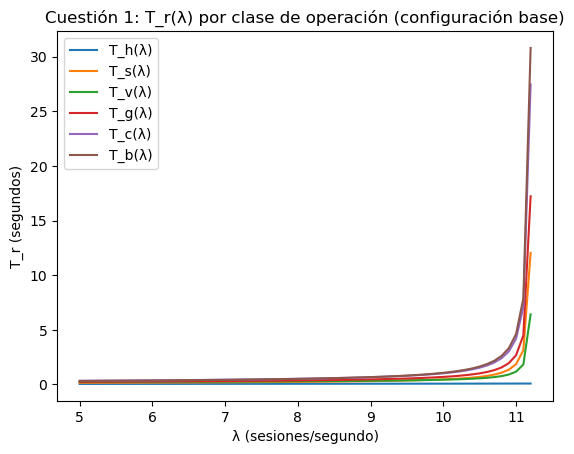

Parada en λ=11.2 porque max(U_i)=0.9971
Recurso más cargado: DS-disk (U=0.9971)


In [133]:
# Configuración base: 1 servidor por recurso
N = {k: 1 for k in K}

# Mezcla base (del enunciado)
fA, fB = 0.25, 0.75

def lambda_r_from_lambda(lam):
    return {r: lam * (fA*nu_A[idx[r]] + fB*nu_B[idx[r]]) for r in R}

def compute_U_and_Tr(lam):
    lam_r = lambda_r_from_lambda(lam)

    # U_i = sum_r (λ_r / N_i) * D_{i,r}
    U = {i: sum((lam_r[r]/N[i]) * D[i][r] for r in R) for i in K}

    # Evitar dividir por 0 si U>=1
    if any(U[i] >= 1.0 for i in K):
        return U, {r: np.inf for r in R}

    # T_{i,r} = D_{i,r} / (1 - U_i)   y  T_r = sum_i T_{i,r}
    Tr = {r: sum(D[i][r] / (1.0 - U[i]) for i in K) for r in R}
    return U, Tr

# ---------- Cuestión 1 ----------
lam_values = []
Tr_series = {r: [] for r in R}
Umax_values = []

lam = 5.0
step = 0.1
stop_U = 0.99

while True:
    U, Tr = compute_U_and_Tr(lam)
    umax = max(U.values())

    lam_values.append(lam)
    Umax_values.append(umax)
    for r in R:
        Tr_series[r].append(Tr[r])

    if umax >= stop_U:
        break
    lam = round(lam + step, 10)

lam_stop = lam_values[-1]
U_stop, _ = compute_U_and_Tr(lam_stop)
bottleneck = max(K, key=lambda i: U_stop[i])

plt.figure()
for r in R:
    plt.plot(lam_values, Tr_series[r], label=f"T_{r}(λ)")
plt.xlabel("λ (sesiones/segundo)")
plt.ylabel("T_r (segundos)")
plt.title("Cuestión 1: T_r(λ) por clase de operación (configuración base)")
plt.legend()
plt.show()

print(f"Parada en λ={lam_stop:.1f} porque max(U_i)={max(U_stop.values()):.4f}")
print(f"Recurso más cargado: {bottleneck} (U={U_stop[bottleneck]:.4f})")


## Cuestión 2

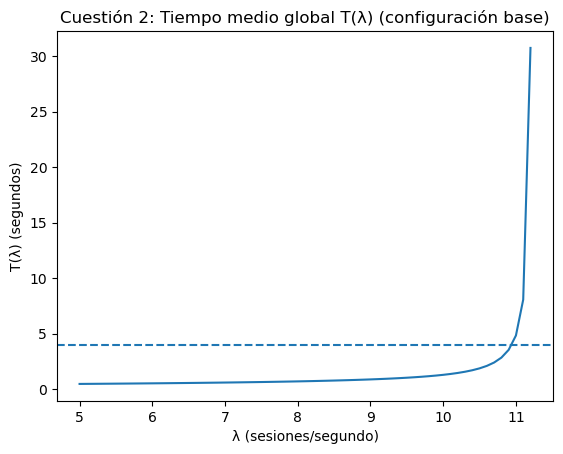

Parada en λ=11.2 porque max(U_i)=0.9971 (bottleneck=DS-disk)
SLA (T<= 4.0s) se viola por primera vez en λ≈11.0 con T≈4.829s


In [134]:
def compute_U_Tr_T(lam):
    lam_r = lambda_r_from_lambda(lam)

    U = {i: sum((lam_r[r]/N[i]) * D[i][r] for r in R) for i in K}
    if any(U[i] >= 1.0 for i in K):
        return U, {r: np.inf for r in R}, np.inf

    Tr = {r: sum(D[i][r] / (1.0 - U[i]) for i in K) for r in R}
    T = sum(Tr[r] * (lam_r[r] / lam) for r in R)
    return U, Tr, T


TSLA = 4.0
lam = 5.0
step = 0.1
stop_U = 0.99

lam_values, T_values, Umax_values = [], [], []

while True:
    U, Tr, T = compute_U_Tr_T(lam)
    umax = max(U.values())

    lam_values.append(lam)
    T_values.append(T)
    Umax_values.append(umax)

    if umax >= stop_U:
        break
    lam = round(lam + step, 10)

# primera violación del SLA
sla_violation = None
for l, t in zip(lam_values, T_values):
    if t > TSLA:
        sla_violation = (l, t)
        break

lam_stop = lam_values[-1]
U_stop, _, _ = compute_U_Tr_T(lam_stop)
bottleneck = max(K, key=lambda i: U_stop[i])

plt.figure()
plt.plot(lam_values, T_values)
plt.axhline(TSLA, linestyle="--")
plt.xlabel("λ (sesiones/segundo)")
plt.ylabel("T(λ) (segundos)")
plt.title("Cuestión 2: Tiempo medio global T(λ) (configuración base)")
plt.show()

print(f"Parada en λ={lam_stop:.1f} porque max(U_i)={max(U_stop.values()):.4f} (bottleneck={bottleneck})")
if sla_violation:
    print(f"SLA (T<= {TSLA}s) se viola por primera vez en λ≈{sla_violation[0]:.1f} con T≈{sla_violation[1]:.3f}s")
else:
    print(f"No se viola SLA (T<= {TSLA}s) en el rango explorado (hasta Umax≈{stop_U}).")

## Cuestión 3


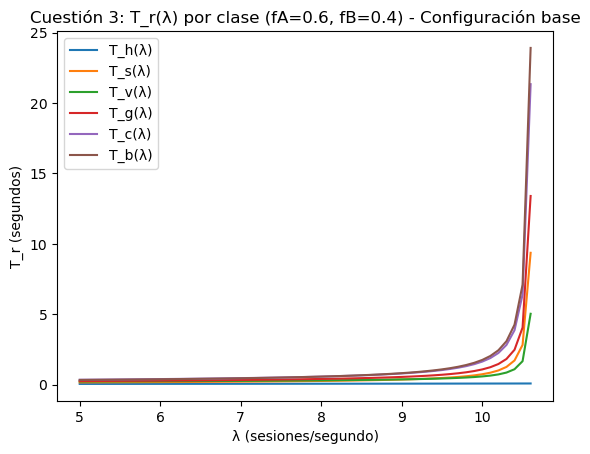

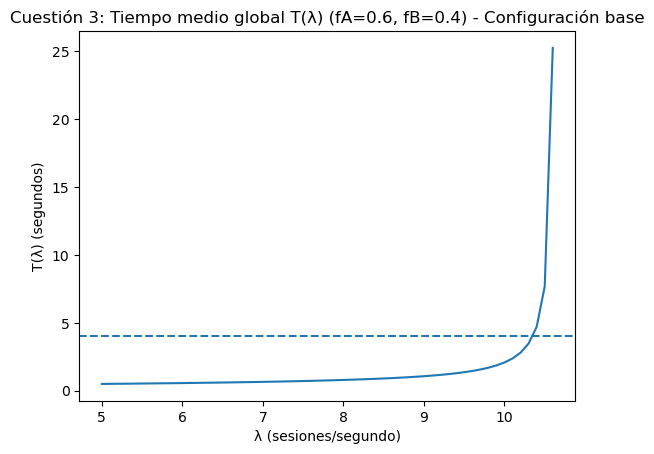

Mezcla: fA=0.6, fB=0.4
Parada en λ=10.6 porque max(U_i)=0.9962 (bottleneck=DS-disk)
SLA (T<= 4.0s) se viola por primera vez en λ≈10.4 con T≈4.704s


In [135]:
fA, fB = 0.60, 0.40
TSLA = 4.0
lam = 5.0
step = 0.1
stop_U = 0.99

lam_values, Umax_values, T_values = [], [], []
Tr_series = {r: [] for r in R}

while True:
    U, Tr, T = compute_U_Tr_T(lam)
    umax = max(U.values())

    lam_values.append(lam)
    Umax_values.append(umax)
    T_values.append(T)
    for r in R:
        Tr_series[r].append(Tr[r])

    if umax >= stop_U:
        break
    lam = round(lam + step, 10)

# SLA first violation
sla_violation = None
for l, t in zip(lam_values, T_values):
    if t > TSLA:
        sla_violation = (l, t)
        break

lam_stop = lam_values[-1]
U_stop, _, _ = compute_U_Tr_T(lam_stop)
bottleneck = max(K, key=lambda i: U_stop[i])

# ---------- Gráficas ----------
plt.figure()
for r in R:
    plt.plot(lam_values, Tr_series[r], label=f"T_{r}(λ)")
plt.xlabel("λ (sesiones/segundo)")
plt.ylabel("T_r (segundos)")
plt.title("Cuestión 3: T_r(λ) por clase (fA=0.6, fB=0.4) - Configuración base")
plt.legend()
plt.show()

plt.figure()
plt.plot(lam_values, T_values)
plt.axhline(TSLA, linestyle="--")
plt.xlabel("λ (sesiones/segundo)")
plt.ylabel("T(λ) (segundos)")
plt.title("Cuestión 3: Tiempo medio global T(λ) (fA=0.6, fB=0.4) - Configuración base")
plt.show()

print(f"Mezcla: fA={fA}, fB={fB}")
print(f"Parada en λ={lam_stop:.1f} porque max(U_i)={max(U_stop.values()):.4f} (bottleneck={bottleneck})")
if sla_violation:
    print(f"SLA (T<= {TSLA}s) se viola por primera vez en λ≈{sla_violation[0]:.1f} con T≈{sla_violation[1]:.3f}s")

## Cuestión 4


In [136]:
def lambda_max_theoretical(fA, fB=None, U_target=0.99):
    if fB is None:
        fB = 1.0 - fA

    mix_nu = {r: (fA * nu_A[idx[r]] + fB * nu_B[idx[r]]) for r in R}

    denom = {}
    for i in K:
        denom[i] = sum(mix_nu[r] * (D[i][r] / N[i]) for r in R)

    lam_max_i = {i: (U_target / denom[i]) if denom[i] > 0 else np.inf for i in K}
    bottleneck = min(lam_max_i, key=lambda i: lam_max_i[i])
    return lam_max_i[bottleneck], bottleneck, lam_max_i

# Ejemplo: para tus dos mezclas anteriores
lam_max_base, bott_base, per_res_base = lambda_max_theoretical(fA=0.25, fB=0.75, U_target=0.90)
lam_max_q3, bott_q3, per_res_q3 = lambda_max_theoretical(fA=0.60, fB=0.40, U_target=0.90)

print("Mezcla base (fA=0.25, fB=0.75):")
print(f"  λ_max ≈ {lam_max_base:.4f}, cuello de botella = {bott_base}")
print("  λ_max por recurso:", per_res_base)

print("\nMezcla cuestión 3 (fA=0.60, fB=0.40):")
print(f"  λ_max ≈ {lam_max_q3:.4f}, cuello de botella = {bott_q3}")
print("  λ_max por recurso:", per_res_q3)

Mezcla base (fA=0.25, fB=0.75):
  λ_max ≈ 10.1098, cuello de botella = DS-disk
  λ_max por recurso: {'WS-CPU': 19.763375171910592, 'WS-disk': 17.74556622247981, 'AS-CPU': 13.871002016432703, 'AS-disk': 27.71366465625958, 'DS-CPU': 25.83965277422821, 'DS-disk': 10.109820908096792}

Mezcla cuestión 3 (fA=0.60, fB=0.40):
  λ_max ≈ 9.5765, cuello de botella = DS-disk
  λ_max por recurso: {'WS-CPU': 18.52845858945652, 'WS-disk': 17.521503663587133, 'AS-CPU': 13.394161769003475, 'AS-disk': 26.26256624002818, 'DS-CPU': 23.971524734255066, 'DS-disk': 9.57646858531376}


## Cuestión 5

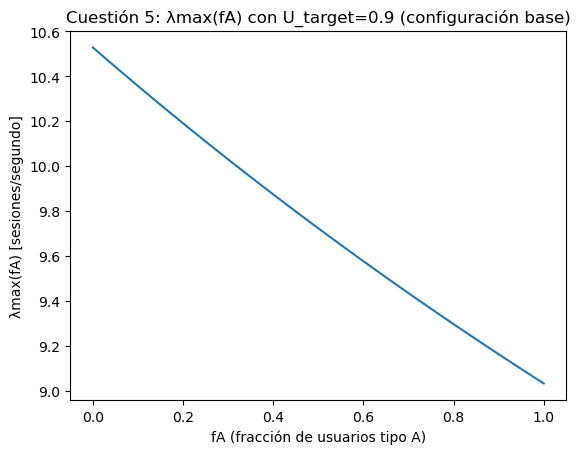

Mezcla más favorable: fA=0.00, fB=1.00
λmax ≈ 10.5287 sesiones/segundo (bottleneck=DS-disk)
Cuellos de botella observados: ['DS-disk']


In [137]:

def lambda_max(fA, U_target=0.99):
    fB = 1.0 - fA
    mix_nu = {r: fA*nu_A[idx[r]] + fB*nu_B[idx[r]] for r in R}

    lam_i = {}
    for i in K:
        denom = sum(mix_nu[r] * (D[i][r]/N[i]) for r in R)
        lam_i[i] = np.inf if denom == 0 else U_target/denom

    bottleneck = min(lam_i, key=lam_i.get)
    return lam_i[bottleneck], bottleneck

U_target = 0.90
fA_vals = np.linspace(0,1,101)
lam_vals = []
bottlenecks = []

for fA in fA_vals:
    lm, b = lambda_max(float(fA), U_target=U_target)
    lam_vals.append(lm)
    bottlenecks.append(b)

best_idx = int(np.argmax(lam_vals))
best_fA = float(fA_vals[best_idx])
best_fB = 1-best_fA
best_lam = float(lam_vals[best_idx])
best_bott = bottlenecks[best_idx]

plt.figure()
plt.plot(fA_vals, lam_vals)
plt.xlabel("fA (fracción de usuarios tipo A)")
plt.ylabel("λmax(fA) [sesiones/segundo]")
plt.title(f"Cuestión 5: λmax(fA) con U_target={U_target} (configuración base)")
plt.show()

print(f"Mezcla más favorable: fA={best_fA:.2f}, fB={best_fB:.2f}")
print(f"λmax ≈ {best_lam:.4f} sesiones/segundo (bottleneck={best_bott})")
print("Cuellos de botella observados:", sorted(set(bottlenecks)))

Asumimos que, según la cuestión 5, la mezcla más favorable es fA = 0 y fB = 1

## Cuestión 6

=== Configuración base (N_i=1) ===
λ_max(U=0.9) = 11.5815 | bottleneck=DS-disk | T(λ_max)=9.0937 s

Top 20 configuraciones:
    total_servers  WS-CPU  WS-disk  AS-CPU  AS-disk  DS-CPU  DS-disk  \
0              16       2        3       3        2       2        4   
1              16       2        2       3        2       2        5   
2              16       2        2       4        2       2        4   
3              16       3        2       3        2       2        4   
4              16       2        2       3        2       3        4   
5              16       2        2       3        3       2        4   
6              15       2        2       3        2       2        4   
7              16       2        3       4        2       2        3   
8              16       3        3       3        2       2        3   
9              16       2        4       3        2       2        3   
10             16       2        3       3        2       3        3   
11          

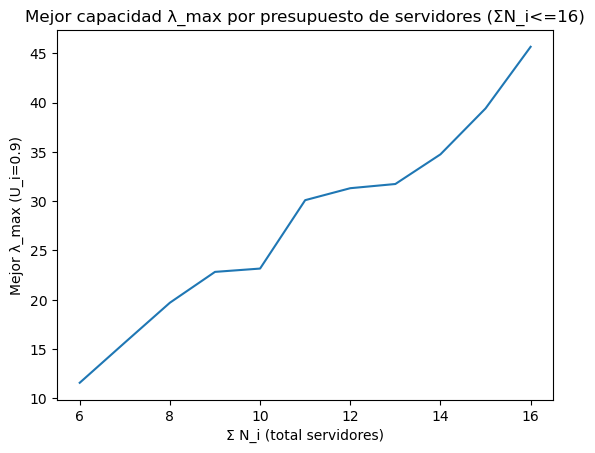

In [138]:
mix_nu = {r: float(nu_B[idx[r]]) for r in R}  # fB=1

# ----------------------- Functions -----------------------
def lambda_max_config(N, U_target=0.90):
    """λ_max(N) = min_i U_target / sum_r mix_nu[r] * D[i][r] / N[i]"""
    lam_i = {}
    for i in K:
        denom = sum(mix_nu[r] * (D[i][r] / N[i]) for r in R)
        lam_i[i] = np.inf if denom == 0 else U_target / denom
    bottleneck = min(lam_i, key=lam_i.get)
    return float(lam_i[bottleneck]), bottleneck

def T_global(N, lam, use_seidmann=True):
    """
    T(N,λ) con λ_r = λ * mix_nu[r]
    U_i = sum_r (λ_r/N_i)*D_{i,r}
    Si use_seidmann:
      T_{i,r} = D_{i,r}*(N_i-1)/N_i + D_{i,r}/(1-U_i)
    """
    lam_r = {r: lam * mix_nu[r] for r in R}
    U = {i: sum((lam_r[r] / N[i]) * D[i][r] for r in R) for i in K}
    if any(U[i] >= 1.0 for i in K):
        return np.inf

    Tr = {}
    for r in R:
        acc = 0.0
        for i in K:
            if D[i][r] == 0:
                continue
            if use_seidmann and N[i] > 1:
                acc += D[i][r] * (N[i]-1)/N[i] + D[i][r] / (1.0 - U[i])
            else:
                acc += D[i][r] / (1.0 - U[i])
        Tr[r] = acc

    T = sum(Tr[r] * (lam_r[r] / lam) for r in R)
    return float(T)

def compositions(total, parts):
    """All integer vectors of length=parts with positive entries summing to total."""
    if parts == 1:
        yield (total,)
        return
    for first in range(1, total - parts + 2):
        for rest in compositions(total - first, parts - 1):
            yield (first,) + rest

U_target = 0.99
max_total_servers = 16

rows = []
gamma = 0

for total in range(len(K), max_total_servers + 1):  # min sum is 6 (all ones)
    for vec in compositions(total, len(K)):
        N = {K[i]: int(vec[i]) for i in range(len(K))}
        lam_max, bott = lambda_max_config(N, U_target=U_target)
        T_at_lam = T_global(N, lam_max, use_seidmann=True)

        gamma += 1
        rows.append({
            "gamma": gamma,
            "total_servers": total,
            **{k: N[k] for k in K},
            "lambda_max_U0.9": lam_max,
            "bottleneck": bott,
            "T_at_lambda_max": T_at_lam,
        })

df = pd.DataFrame(rows)

# Base configuration
N_base = {k: 1 for k in K}
lam_base, bott_base = lambda_max_config(N_base, U_target=U_target)
T_base = T_global(N_base, lam_base, use_seidmann=True)

# Ordenar y mostrar top
df_sorted = df.sort_values(["lambda_max_U0.9", "T_at_lambda_max"], ascending=[False, True]).reset_index(drop=True)
top20 = df_sorted.head(20).copy()
top20["impr_lambda_vs_base"] = top20["lambda_max_U0.9"] / lam_base
top20["impr_T_vs_base"] = top20["T_at_lambda_max"] / T_base

print("=== Configuración base (N_i=1) ===")
print(f"λ_max(U=0.9) = {lam_base:.4f} | bottleneck={bott_base} | T(λ_max)={T_base:.4f} s")

print("\nTop 20 configuraciones:")
print(top20[["total_servers"] + K + ["lambda_max_U0.9","bottleneck","T_at_lambda_max","impr_lambda_vs_base","impr_T_vs_base"]])

# Guardar dataset para aprendizaje
csv_path = "learning_db_T_gamma_max16.csv"
df.to_csv(csv_path, index=False)
print(f"\nDataset guardado en: {csv_path}")

# Gráfica: mejor λmax por total de servidores
best_by_total = df.loc[df.groupby("total_servers")["lambda_max_U0.9"].idxmax()].sort_values("total_servers")
plt.figure()
plt.plot(best_by_total["total_servers"], best_by_total["lambda_max_U0.9"])
plt.xlabel("Σ N_i (total servidores)")
plt.ylabel("Mejor λ_max (U_i=0.9)")
plt.title("Mejor capacidad λ_max por presupuesto de servidores (ΣN_i<=16)")
plt.show()

if os.path.exists(csv_path):
    os.remove(csv_path)

# Parte 4

## Cuestión 1

In [139]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple
import math

# Recursos (mismos K de toda la práctica)
K = ["WS-CPU", "WS-disk", "AS-CPU", "AS-disk", "DS-CPU", "DS-disk"]

NVec = Dict[str, int]
GPredict = Callable[[NVec, float], float]  # devuelve T estimado: g(N, λ)

@dataclass(frozen=True)
class SLA:
    Tmax: float        # umbral de tiempo de respuesta (seg)
    lam_max: float     # λmax del SLA (para normalizar utilidad)
    Nmax: int          # máximo total de servidores permitido

@dataclass(frozen=True)
class UtilityWeights:
    w1: float
    w2: float
    w3: float

def H_penalty(T: float, Tmax: float) -> float:
    """
    H(t) según el enunciado:
      0 si T < Tmax
      (T - Tmax)/Tmax si Tmax <= T <= 1.5*Tmax
      1 si T > 1.5*Tmax
    """
    if T < Tmax:
        return 0.0
    if T <= 1.5 * Tmax:
        return (T - Tmax) / Tmax
    return 1.0

def utility(mu_weights: UtilityWeights, sla: SLA, lam: float, T: float, N_total: int) -> float:
    # Normalizaciones del enunciado
    term1 = lam / sla.lam_max
    term2 = 1.0 - (N_total / sla.Nmax)
    term3 = 1.0 - H_penalty(T, sla.Tmax)
    return mu_weights.w1 * term1 + mu_weights.w2 * term2 + mu_weights.w3 * term3

def n_total(N: NVec) -> int:
    return sum(N.values())

def feasible(N: NVec, sla: SLA) -> bool:
    # Ni >= 1 y sum(Ni) <= Nmax
    return all(N[i] >= 1 for i in K) and n_total(N) <= sla.Nmax

def neighbors(N: NVec, sla: SLA) -> List[NVec]:
    """
    Vecinos: sumar/restar 1 servidor en un recurso (manteniendo factibilidad).
    (Puedes restringir esto a movimientos por capas si tu profe lo exige.)
    """
    neigh = []
    for i in K:
        # +1 en i
        Np = dict(N)
        Np[i] += 1
        if feasible(Np, sla):
            neigh.append(Np)

        # -1 en i
        Nm = dict(N)
        Nm[i] -= 1
        if feasible(Nm, sla):
            neigh.append(Nm)
    return neigh

def decide_next_configuration(
    N_current: NVec,
    lam_hat_ti2: float,
    g_predict: GPredict,
    sla: SLA,
    weights: UtilityWeights,
    max_iters: int = 200
) -> Tuple[NVec, float, float]:
    """
    Política de decisión (Cuestión 1):
      - usa g(N, λ̂) para predecir T futuro
      - impone SLA: T_pred <= Tmax
      - maximiza utilidad µ(ti+2)
    Devuelve: (N_best, T_pred_best, mu_best)
    """
    if not feasible(N_current, sla):
        raise ValueError("N_current no es factible según Nmax/Ni>=1")

    # Estado inicial
    N_best = dict(N_current)
    T_best = g_predict(N_best, lam_hat_ti2)
    # Si el punto inicial viola SLA, buscamos igualmente mejoras (reparación)
    mu_best = utility(weights, sla, lam_hat_ti2, T_best, n_total(N_best)) if T_best <= sla.Tmax else -math.inf

    improved = True
    it = 0

    while improved and it < max_iters:
        it += 1
        improved = False

        for Nn in neighbors(N_best, sla):
            Tn = g_predict(Nn, lam_hat_ti2)

            # Restricción SLA: solo aceptamos candidatos que cumplan
            if Tn > sla.Tmax:
                continue

            mun = utility(weights, sla, lam_hat_ti2, Tn, n_total(Nn))

            if mun > mu_best:
                N_best, T_best, mu_best = Nn, Tn, mun
                improved = True

        # Si no hay mejora SLA-feasible, paramos

    return N_best, T_best, mu_best

# ---------------- EJEMPLO DE USO ----------------
if __name__ == "__main__":
    # Configuración actual (ejemplo)
    N0 = {k: 1 for k in K}

    # SLA y pesos (ajusta a tu práctica)
    sla = SLA(Tmax=4.0, lam_max=10.5, Nmax=16)
    w = UtilityWeights(w1=0.4, w2=0.3, w3=0.3)  # deben sumar 1

    # Predictor g(N,λ) (placeholder -> lo harás en la cuestión 2)
    def g_predict_dummy(N: NVec, lam: float) -> float:
        # Ejemplo tonto: penaliza por carga y premia por servidores
        return 1.0 + 0.5 * (lam / 10.0) + 2.0 / max(1, n_total(N))

    lam_hat = 9.0  # λ̂(ti+2)

    N_new, T_pred, mu_pred = decide_next_configuration(
        N_current=N0,
        lam_hat_ti2=lam_hat,
        g_predict=g_predict_dummy,
        sla=sla,
        weights=w
    )

    print("Nueva configuración:", N_new)
    print("T_pred:", T_pred)
    print("µ_pred:", mu_pred)

Nueva configuración: {'WS-CPU': 1, 'WS-disk': 1, 'AS-CPU': 1, 'AS-disk': 1, 'DS-CPU': 1, 'DS-disk': 1}
T_pred: 1.7833333333333332
µ_pred: 0.8303571428571428


## Cuestión 2


Dataset guardado en: learning_db_T_gamma_max16.csv


/var/folders/77/6t1fp7hd3bsbwjkb0pg8hbv40000gn/T/ipykernel_6032/3252639379.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(design_matrix(N_vec, lam_vec) @ w)


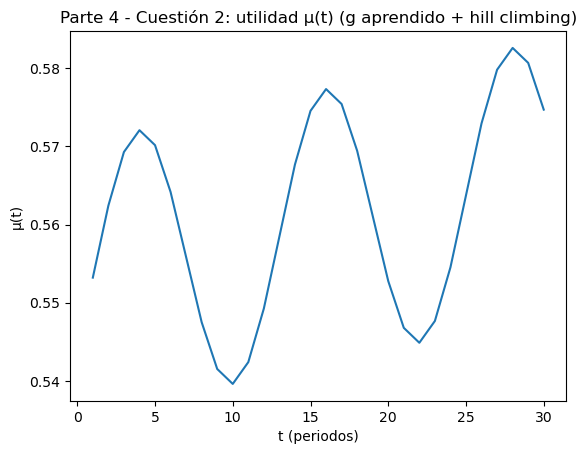

In [140]:
Tmax = 4.0
Nmax = 16
U_target = 0.99

def solve_nu(P):
    n = P.shape[0]
    A = np.zeros((n,n))
    b = np.zeros(n)
    A[0, idx["e"]] = 1.0
    b[0] = 1.0
    eq = 1
    for st in states:
        if st == "e":
            continue
        j = idx[st]
        A[eq, j] = 1.0
        A[eq, :] -= P[:, j]
        eq += 1
    return np.linalg.solve(A, b)

nu_B = solve_nu(P_B)
mix_nu = {r: float(nu_B[idx[r]]) for r in R}


def T_real(N, lam):
    lam_r = {r: lam * mix_nu[r] for r in R}
    U = {i: sum((lam_r[r] / N[i]) * D[i][r] for r in R) for i in K}
    if any(U[i] >= 1.0 for i in K):
        return np.inf

    Tr = {}
    for r in R:
        acc = 0.0
        for i in K:
            if D[i][r] == 0:
                continue
            if N[i] > 1:
                acc += D[i][r] * (N[i]-1)/N[i] + D[i][r] / (1.0 - U[i])
            else:
                acc += D[i][r] / (1.0 - U[i])
        Tr[r] = acc
    return float(sum(Tr[r] * (lam_r[r] / lam) for r in R))

def lambda_max_config(N, U_target=0.90):
    lam_i = {}
    for i in K:
        denom = sum(mix_nu[r] * (D[i][r] / N[i]) for r in R)
        lam_i[i] = np.inf if denom == 0 else U_target / denom
    bottleneck = min(lam_i, key=lam_i.get)
    return float(lam_i[bottleneck]), bottleneck

# ------------------------------ Build learning DB if missing ------------------------------
csv_path = "learning_db_T_gamma_max16.csv"
df.to_csv(csv_path, index=False)
print(f"\nDataset guardado en: {csv_path}")

def compositions(total, parts):
    if parts == 1:
        yield (total,)
        return
    for first in range(1, total - parts + 2):
        for rest in compositions(total - first, parts - 1):
            yield (first,) + rest

if not os.path.exists(csv_path):
    rows = []
    gamma = 0
    for total in range(len(K), Nmax + 1):
        for vec in compositions(total, len(K)):
            N = {K[i]: int(vec[i]) for i in range(len(K))}
            lam_max, bott = lambda_max_config(N, U_target=U_target)
            T_at = T_real(N, lam_max)
            gamma += 1
            rows.append({
                "gamma": gamma,
                "total_servers": total,
                **{k: N[k] for k in K},
                "lambda_max_U0.9": lam_max,
                "bottleneck": bott,
                "T_at_lambda_max": T_at,
            })
    pd.DataFrame(rows).to_csv(csv_path, index=False)

df_learn = pd.read_csv(csv_path)

# ------------------------------ Learn g(N,λ) from DB ------------------------------
X = df_learn[K].to_numpy(dtype=float)
lam_col = df_learn["lambda_max_U0.9"].to_numpy(dtype=float).reshape(-1, 1)
y = df_learn["T_at_lambda_max"].to_numpy(dtype=float)

def design_matrix(N_mat, lam_vec):
    lam = lam_vec.reshape(-1, 1)
    ones = np.ones((N_mat.shape[0], 1))
    feats = [ones, lam, lam**2, N_mat, N_mat**2, lam * N_mat]
    return np.hstack(feats)

Phi = design_matrix(X, lam_col)
ridge = 1e-6
w = np.linalg.solve(Phi.T @ Phi + ridge*np.eye(Phi.shape[1]), Phi.T @ y)

def g_predict(N_dict, lam):
    N_vec = np.array([[N_dict[k] for k in K]], dtype=float)
    lam_vec = np.array([[lam]], dtype=float)
    return float(design_matrix(N_vec, lam_vec) @ w)

# ------------------------------ Utility µ(t) (Eq. 5) ------------------------------
lambda_max_SLA = float(df_learn["lambda_max_U0.9"].max())
w1, w2, w3 = 0.4, 0.3, 0.3  # sum=1

def H_from_T(T):
    if T < Tmax:
        return 0.0
    if Tmax <= T <= 1.5*Tmax:
        return float((T - Tmax) / Tmax)
    return 1.0

def utility(lam, T, Ntot):
    H = H_from_T(T)
    return (w1 * (lam / lambda_max_SLA)
            + w2 * (1.0 - (Ntot / Nmax))
            + w3 * (1.0 - H))

# ------------------------------ Decision: hill climbing ------------------------------
def neighbors(N):
    Ntot = sum(N.values())
    for k in K:
        if Ntot < Nmax:
            N2 = dict(N); N2[k] += 1
            yield N2
        if N[k] > 1:
            N2 = dict(N); N2[k] -= 1
            yield N2

def best_config_hill_climb(N_start, lam_hat):
    N_curr = dict(N_start)
    improved = True
    visited = set()
    def keyN(N): return tuple(N[k] for k in K)

    while improved:
        improved = False
        visited.add(keyN(N_curr))

        T_pred_curr = g_predict(N_curr, lam_hat)
        best_mu = -1e9 if T_pred_curr > Tmax else utility(lam_hat, T_pred_curr, sum(N_curr.values()))
        best_N = N_curr

        for N_nb in neighbors(N_curr):
            if keyN(N_nb) in visited:
                continue
            T_pred = g_predict(N_nb, lam_hat)
            if T_pred > Tmax:
                continue
            mu_pred = utility(lam_hat, T_pred, sum(N_nb.values()))
            if mu_pred > best_mu + 1e-9:
                best_mu = mu_pred
                best_N = N_nb
                improved = True

        N_curr = best_N
    return N_curr

# ------------------------------ Simulate periods t ------------------------------
T_periods = 30
t = np.arange(1, T_periods + 1)

lam_true = 7.5 + 2.0*np.sin(2*np.pi*(t-1)/12) + 0.05*(t-1)   # smooth load
rng = np.random.default_rng(42)
lam_hat_series = np.maximum(0.1, lam_true + rng.normal(0, 0.15, size=T_periods))

# start with base config
N_planned = {1: {k:1 for k in K}, 2: {k:1 for k in K}}  # delay 2 periods
N_hist, T_hist, mu_hist = [], [], []

for i in range(T_periods):
    period = i + 1
    N_curr = dict(N_planned.get(period, N_planned.get(period-1, N_planned[1])))

    lam_obs = float(lam_true[i])
    T_obs = T_real(N_curr, lam_obs)
    mu_obs = utility(lam_obs, T_obs, sum(N_curr.values()))

    N_hist.append(N_curr)
    T_hist.append(T_obs)
    mu_hist.append(mu_obs)

    if period + 2 <= T_periods:
        lam_future_hat = float(lam_hat_series[period+1])  # (t+2) index
        N_planned[period + 2] = best_config_hill_climb(N_curr, lam_future_hat)

res = pd.DataFrame({
    "t": t,
    "lambda(t)": lam_true,
    "T_real(t)": T_hist,
    "mu(t)": mu_hist,
    "N_total(t)": [sum(N.values()) for N in N_hist],
})

# ------------------------------ Required plot: µ(t) ------------------------------
plt.figure()
plt.plot(res["t"], res["mu(t)"])
plt.xlabel("t (periodos)")
plt.ylabel("µ(t)")
plt.title("Parte 4 - Cuestión 2: utilidad µ(t) (g aprendido + hill climbing)")
plt.show()

if os.path.exists(csv_path):
    os.remove(csv_path)

## Cuestión 3

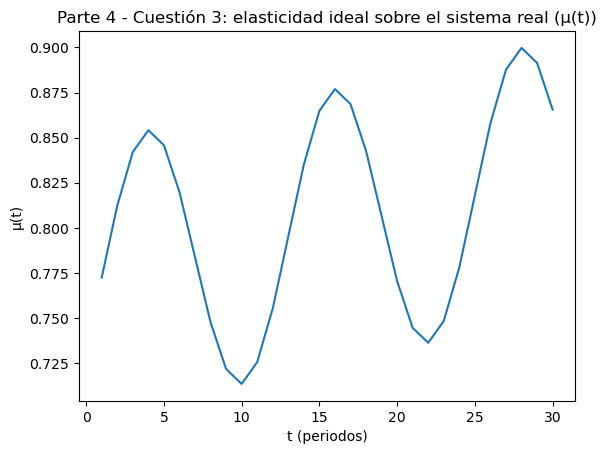

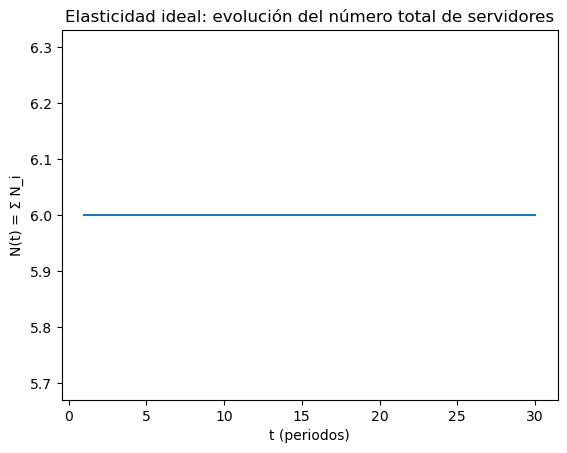

In [141]:
def T_real(N, lam):
    lam_r = {r: lam * mix_nu[r] for r in R}
    U = {i: sum((lam_r[r] / N[i]) * D[i][r] for r in R) for i in K}
    if any(U[i] >= 1.0 for i in K):
        return np.inf

    Tr = {}
    for r in R:
        acc = 0.0
        for i in K:
            if D[i][r] == 0:
                continue
            if N[i] > 1:
                acc += D[i][r] * (N[i]-1)/N[i] + D[i][r] / (1.0 - U[i])
            else:
                acc += D[i][r] / (1.0 - U[i])
        Tr[r] = acc
    return float(sum(Tr[r] * (lam_r[r] / lam) for r in R))

# ------------------------------ Utility µ(t) (Eq. 5) ------------------------------
N_base = {k: 1 for k in K}

def lambda_max_config(N, U_target=0.90):
    lam_i = {}
    for i in K:
        denom = sum(mix_nu[r] * (D[i][r] / N[i]) for r in R)
        lam_i[i] = np.inf if denom == 0 else U_target / denom
    bottleneck = min(lam_i, key=lam_i.get)
    return float(lam_i[bottleneck])

lambda_max_SLA = lambda_max_config(N_base, U_target=0.90)

def H_from_T(T):
    if T < Tmax:
        return 0.0
    if Tmax <= T <= 1.5*Tmax:
        return float((T - Tmax) / Tmax)
    return 1.0

def utility(lam, T, Ntot):
    H = H_from_T(T)
    return (w1 * (lam / lambda_max_SLA)
            + w2 * (1.0 - (Ntot / Nmax))
            + w3 * (1.0 - H))

# ------------------------------ Generate all configs ΣN<=16 ------------------------------
def compositions(total, parts):
    if parts == 1:
        yield (total,)
        return
    for first in range(1, total - parts + 2):
        for rest in compositions(total - first, parts - 1):
            yield (first,) + rest

all_configs = []
for total in range(len(K), Nmax + 1):
    for vec in compositions(total, len(K)):
        all_configs.append({K[i]: int(vec[i]) for i in range(len(K))})

# ------------------------------ Elasticidad ideal (Cuestión 3) ------------------------------
def choose_best_config_ideal(lam_future):
    """
    Elasticidad ideal:
    - conoce el sistema real T_real
    - para una carga futura λ elige la configuración (ΣN<=16) que maximiza µ
      cumpliendo SLA (T<=Tmax). Si empate, menor coste (ΣN).
    """
    best = None
    best_mu = -1e18
    best_cost = 10**9

    for N in all_configs:
        T = T_real(N, lam_future)
        if T > Tmax:
            continue
        cost = sum(N.values())
        mu = utility(lam_future, T, cost)
        if (mu > best_mu + 1e-12) or (abs(mu - best_mu) <= 1e-12 and cost < best_cost):
            best_mu = mu
            best = N
            best_cost = cost

    if best is None:
        best = min(all_configs, key=lambda N: T_real(N, lam_future))
    return dict(best)

# ------------------------------ Simulate periods t ------------------------------
T_periods = 30
t = np.arange(1, T_periods + 1)
lam_true = 7.5 + 2.0*np.sin(2*np.pi*(t-1)/12) + 0.05*(t-1)

# Delay: decide N(t+2) using perfect knowledge of λ(t+2)
N_planned = {1: dict(N_base), 2: dict(N_base)}
N_hist, T_hist, mu_hist = [], [], []

for i in range(T_periods):
    period = i + 1
    N_curr = dict(N_planned.get(period, N_planned.get(period-1, N_base)))

    lam_obs = float(lam_true[i])
    T_obs = T_real(N_curr, lam_obs)
    mu_obs = utility(lam_obs, T_obs, sum(N_curr.values()))

    N_hist.append(N_curr)
    T_hist.append(T_obs)
    mu_hist.append(mu_obs)

    if period + 2 <= T_periods:
        lam_future = float(lam_true[period+1])  # (t+2)
        N_planned[period + 2] = choose_best_config_ideal(lam_future)

res_ideal = pd.DataFrame({
    "t": t,
    "lambda(t)": lam_true,
    "T_real(t)": T_hist,
    "mu_ideal(t)": mu_hist,
    "N_total(t)": [sum(N.values()) for N in N_hist],
})

# Plot µ(t)
plt.figure()
plt.plot(res_ideal["t"], res_ideal["mu_ideal(t)"])
plt.xlabel("t (periodos)")
plt.ylabel("µ(t)")
plt.title("Parte 4 - Cuestión 3: elasticidad ideal sobre el sistema real (µ(t))")
plt.show()

# Plot N(t)
plt.figure()
plt.plot(res_ideal["t"], res_ideal["N_total(t)"])
plt.xlabel("t (periodos)")
plt.ylabel("N(t) = Σ N_i")
plt.title("Elasticidad ideal: evolución del número total de servidores")
plt.show()

## Cuestión 4

/var/folders/77/6t1fp7hd3bsbwjkb0pg8hbv40000gn/T/ipykernel_6032/4139295185.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(design_matrix(N_vec, lam_vec) @ w)


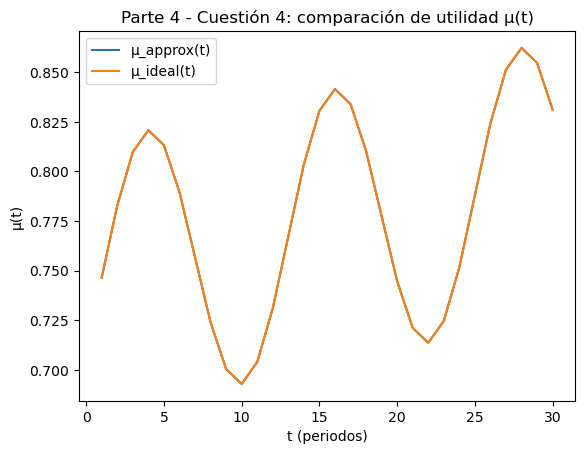

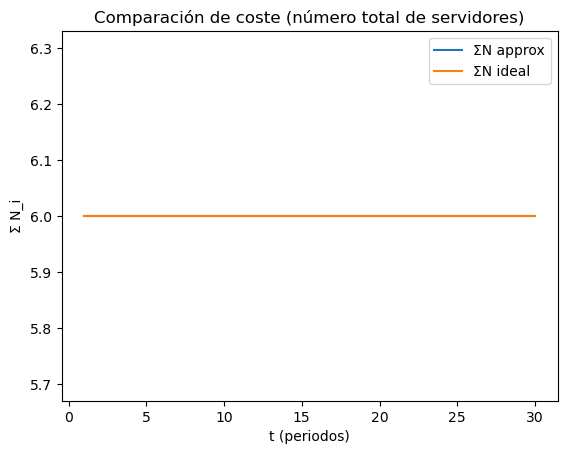

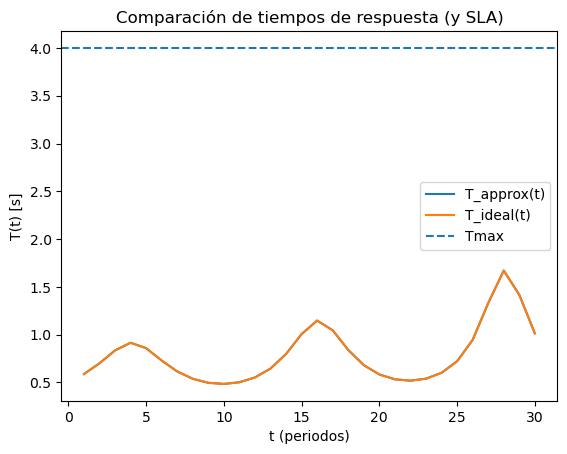

In [142]:
def T_real(N, lam):
    lam_r = {r: lam * mix_nu[r] for r in R}
    U = {i: sum((lam_r[r] / N[i]) * D[i][r] for r in R) for i in K}
    if any(U[i] >= 1.0 for i in K):
        return np.inf
    Tr = {}
    for r in R:
        acc = 0.0
        for i in K:
            if D[i][r] == 0:
                continue
            if N[i] > 1:
                acc += D[i][r] * (N[i]-1)/N[i] + D[i][r] / (1.0 - U[i])
            else:
                acc += D[i][r] / (1.0 - U[i])
        Tr[r] = acc
    return float(sum(Tr[r] * (lam_r[r] / lam) for r in R))

def lambda_max_config(N, U_target=0.90):
    lam_i = {}
    for i in K:
        denom = sum(mix_nu[r] * (D[i][r] / N[i]) for r in R)
        lam_i[i] = np.inf if denom == 0 else U_target / denom
    bottleneck = min(lam_i, key=lam_i.get)
    return float(lam_i[bottleneck])

# ------------------------------ Utility µ(t) ------------------------------
N_base = {k: 1 for k in K}
lambda_max_SLA = lambda_max_config(N_base, U_target=U_target)

def H_from_T(T):
    if T < Tmax:
        return 0.0
    if Tmax <= T <= 1.5*Tmax:
        return float((T - Tmax) / Tmax)
    return 1.0

def utility(lam, T, Ntot):
    H = H_from_T(T)
    return (w1 * (lam / lambda_max_SLA)
            + w2 * (1.0 - (Ntot / Nmax))
            + w3 * (1.0 - H))

# ------------------------------ Learning DB (build if missing) ------------------------------
csv_path = "learning_db_T_gamma_max16.csv"

def compositions(total, parts):
    if parts == 1:
        yield (total,)
        return
    for first in range(1, total - parts + 2):
        for rest in compositions(total - first, parts - 1):
            yield (first,) + rest

if not os.path.exists(csv_path):
    rows = []
    gamma = 0
    for total in range(len(K), Nmax + 1):
        for vec in compositions(total, len(K)):
            N = {K[i]: int(vec[i]) for i in range(len(K))}
            lam_max = lambda_max_config(N, U_target=U_target)
            T_at = T_real(N, lam_max)
            gamma += 1
            rows.append({
                "gamma": gamma,
                "total_servers": total,
                **{k: N[k] for k in K},
                "lambda_max_U0.9": lam_max,
                "T_at_lambda_max": T_at,
            })
    pd.DataFrame(rows).to_csv(csv_path, index=False)

df_learn = pd.read_csv(csv_path)

# ------------------------------ Learn g(N,λ) from DB ------------------------------
X = df_learn[K].to_numpy(dtype=float)
lam_col = df_learn["lambda_max_U0.9"].to_numpy(dtype=float).reshape(-1, 1)
y = df_learn["T_at_lambda_max"].to_numpy(dtype=float)

def design_matrix(N_mat, lam_vec):
    lam = lam_vec.reshape(-1, 1)
    ones = np.ones((N_mat.shape[0], 1))
    feats = [ones, lam, lam**2, N_mat, N_mat**2, lam * N_mat]
    return np.hstack(feats)

Phi = design_matrix(X, lam_col)
ridge = 1e-6
w = np.linalg.solve(Phi.T @ Phi + ridge*np.eye(Phi.shape[1]), Phi.T @ y)

def g_predict(N_dict, lam):
    N_vec = np.array([[N_dict[k] for k in K]], dtype=float)
    lam_vec = np.array([[lam]], dtype=float)
    return float(design_matrix(N_vec, lam_vec) @ w)

# ------------------------------ Search space ΣN<=16 ------------------------------
all_configs = []
for total in range(len(K), Nmax + 1):
    for vec in compositions(total, len(K)):
        all_configs.append({K[i]: int(vec[i]) for i in range(len(K))})

# ------------------------------ Mechanisms ------------------------------
def neighbors(N):
    Ntot = sum(N.values())
    for k in K:
        if Ntot < Nmax:
            N2 = dict(N); N2[k] += 1
            yield N2
        if N[k] > 1:
            N2 = dict(N); N2[k] -= 1
            yield N2

def best_config_hill_climb_approx(N_start, lam_hat):
    """Maximize µ using predicted T=g(N,λ), enforcing predicted SLA g<=Tmax."""
    N_curr = dict(N_start)
    improved = True
    visited = set()
    def keyN(N): return tuple(N[k] for k in K)

    while improved:
        improved = False
        visited.add(keyN(N_curr))

        T_pred_curr = g_predict(N_curr, lam_hat)
        best_mu = -1e9 if T_pred_curr > Tmax else utility(lam_hat, T_pred_curr, sum(N_curr.values()))
        best_N = N_curr

        for N_nb in neighbors(N_curr):
            if keyN(N_nb) in visited:
                continue
            T_pred = g_predict(N_nb, lam_hat)
            if T_pred > Tmax:
                continue
            mu_pred = utility(lam_hat, T_pred, sum(N_nb.values()))
            if mu_pred > best_mu + 1e-9:
                best_mu = mu_pred
                best_N = N_nb
                improved = True

        N_curr = best_N
    return N_curr

def best_config_ideal(lam_future):
    """Maximize µ using real T_real(N,λ), enforcing SLA; tiebreak: min cost."""
    best = None
    best_mu = -1e18
    best_cost = 10**9
    for N in all_configs:
        T = T_real(N, lam_future)
        if T > Tmax:
            continue
        cost = sum(N.values())
        mu = utility(lam_future, T, cost)
        if (mu > best_mu + 1e-12) or (abs(mu - best_mu) <= 1e-12 and cost < best_cost):
            best_mu = mu
            best = N
            best_cost = cost
    if best is None:
        best = min(all_configs, key=lambda N: T_real(N, lam_future))
    return dict(best)

# ------------------------------ Simulation ------------------------------
T_periods = 30
delay = 2
t = np.arange(1, T_periods + 1)

# Same λ(t) as before (smooth)
lam_true = 7.5 + 2.0*np.sin(2*np.pi*(t-1)/12) + 0.05*(t-1)

# Prediction model (perfect for a fair comparison)
lam_hat = lam_true.copy()

def run_mechanism(kind: str):
    planned = {1: dict(N_base), 2: dict(N_base)}
    N_hist, T_hist, mu_hist = [], [], []
    for i in range(T_periods):
        period = i + 1
        N_curr = dict(planned.get(period, planned.get(period-1, N_base)))

        lam_obs = float(lam_true[i])
        T_obs = T_real(N_curr, lam_obs)
        mu_obs = utility(lam_obs, T_obs, sum(N_curr.values()))

        N_hist.append(N_curr)
        T_hist.append(T_obs)
        mu_hist.append(mu_obs)

        if period + delay <= T_periods:
            if kind == "approx":
                planned[period + delay] = best_config_hill_climb_approx(N_curr, float(lam_hat[period+delay-1]))
            else:
                planned[period + delay] = best_config_ideal(float(lam_true[period+delay-1]))
    return N_hist, np.array(T_hist), np.array(mu_hist)

N_a, T_a, mu_a = run_mechanism("approx")
N_i, T_i, mu_i = run_mechanism("ideal")

# ------------------------------ Comparison outputs ------------------------------
res = pd.DataFrame({
    "t": t,
    "lambda(t)": lam_true,
    "T_approx(t)": T_a,
    "T_ideal(t)": T_i,
    "mu_approx(t)": mu_a,
    "mu_ideal(t)": mu_i,
    "Ntot_approx": [sum(N.values()) for N in N_a],
    "Ntot_ideal":  [sum(N.values()) for N in N_i],
})

def metrics(T, mu, N_list):
    return {
        "mu_avg": float(np.mean(mu)),
        "mu_min": float(np.min(mu)),
        "SLA_violations": int(np.sum(T > Tmax)),
        "T_avg": float(np.mean(T[np.isfinite(T)])),
        "N_avg": float(np.mean([sum(N.values()) for N in N_list])),
    }

metrics_df = pd.DataFrame([
    {"mecanismo": "aprox (g + hill climbing)", **metrics(T_a, mu_a, N_a)},
    {"mecanismo": "ideal (real + búsqueda global)", **metrics(T_i, mu_i, N_i)},
])

# ------------------------------ Plots ------------------------------
plt.figure()
plt.plot(t, mu_a, label="µ_approx(t)")
plt.plot(t, mu_i, label="µ_ideal(t)")
plt.xlabel("t (periodos)")
plt.ylabel("µ(t)")
plt.title("Parte 4 - Cuestión 4: comparación de utilidad µ(t)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, res["Ntot_approx"], label="ΣN approx")
plt.plot(t, res["Ntot_ideal"], label="ΣN ideal")
plt.xlabel("t (periodos)")
plt.ylabel("Σ N_i")
plt.title("Comparación de coste (número total de servidores)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, T_a, label="T_approx(t)")
plt.plot(t, T_i, label="T_ideal(t)")
plt.axhline(Tmax, linestyle="--", label="Tmax")
plt.xlabel("t (periodos)")
plt.ylabel("T(t) [s]")
plt.title("Comparación de tiempos de respuesta (y SLA)")
plt.legend()
plt.show()

if os.path.exists(csv_path):
    os.remove(csv_path)